In [1]:
import numpy as np

from keras.models import Sequential
from keras.layers import Dense, Flatten

import tensorflow as tf

import matplotlib.pyplot as plt

In [2]:
def imgshow(img):
    plt.close()
    plt.imshow(img)
    plt.show()

In [3]:
fashion = tf.keras.datasets.fashion_mnist

In [4]:
(train_images, train_labels), (test_images, test_labels) = fashion.load_data()

In [5]:
train_images.shape

(60000, 28, 28)

9


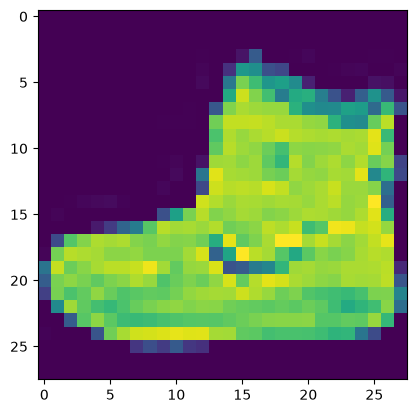

In [6]:
print(train_labels[0])
imgshow(train_images[0])

In [7]:
class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankel boot']

In [8]:
train_images = train_images / 255
test_images = test_images / 255

In [9]:
model = Sequential()
model.add(Flatten(input_shape= (28,28)))
model.add(Dense(128, activation= 'relu'))
model.add(Dense(10))

model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits= True), optimizer= 'adam', metrics=['accuracy'])

model.summary()

c:\Users\Matin\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
test_loss, test_accuracy = model.evaluate(test_images, test_labels)

print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1024 - loss: 2.3807
Test Accuracy: 0.10239999741315842


In [11]:
from keras_visualizer import visualizer
visualizer(model, file_name= 'DL_model',  file_format= 'png')

In [12]:
h = model.fit(train_images, train_labels, epochs= 20, validation_split=0.1)

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8241 - loss: 0.5030 - val_accuracy: 0.8607 - val_loss: 0.3877
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8620 - loss: 0.3808 - val_accuracy: 0.8572 - val_loss: 0.4026
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8760 - loss: 0.3396 - val_accuracy: 0.8612 - val_loss: 0.3855
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8832 - loss: 0.3151 - val_accuracy: 0.8713 - val_loss: 0.3561
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8915 - loss: 0.2970 - val_accuracy: 0.8833 - val_loss: 0.3218
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8958 - loss: 0.2839 - val_accuracy: 0.8812 - val_loss: 0.3263
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8997 - loss: 0.2691 - val_accuracy: 0.8763 - val_loss: 0.3343
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9044 - loss: 0.2566 - 

In [13]:
y_pred = model.predict(test_images)
y_pred[0]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


array([-27.899158 , -23.083544 , -18.065952 , -23.908203 , -28.748758 ,
        -2.7124963, -23.337038 ,   2.2641585, -14.235483 ,   6.961594 ],
      dtype=float32)

In [14]:
predicted_labels = tf.argmax(y_pred, axis=1)

print("Predicted:", predicted_labels[0].numpy())
print("Actual:", test_labels[0])

Predicted: 9
Actual: 9


In [15]:
test_loss, test_accuracy = model.evaluate(test_images, test_labels)

print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8834 - loss: 0.3727
Test Accuracy: 0.883400022983551


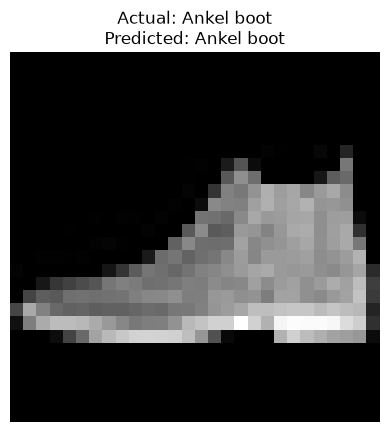

In [16]:
predicted_label = tf.argmax(y_pred[0]).numpy()
plt.close()
plt.imshow(test_images[0], cmap='gray')
plt.title(
    f"Actual: {class_names[test_labels[0]]}\n"
    f"Predicted: {class_names[predicted_label]}"
)
plt.axis('off')
plt.show()

9


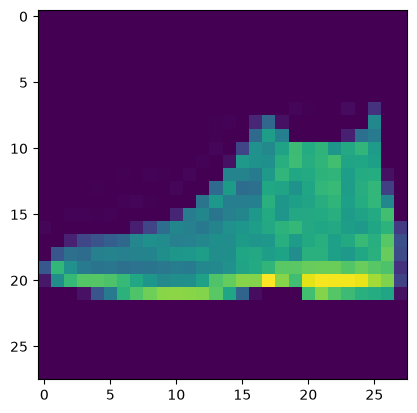

In [17]:
print(test_labels[0])
imgshow(test_images[0])

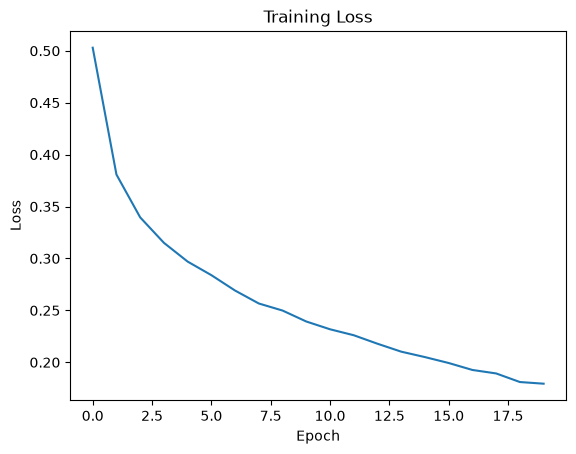

In [18]:
plt.plot(h.history['loss'])
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

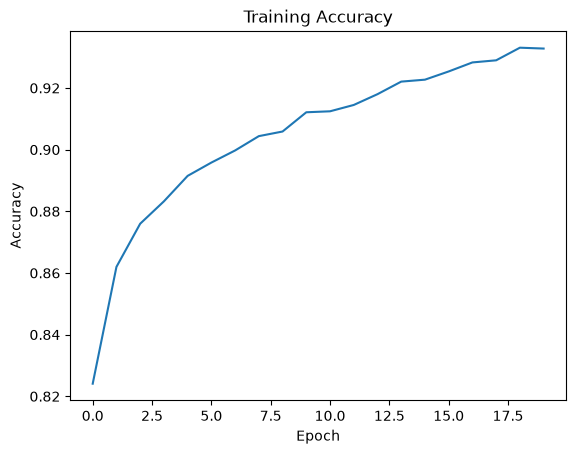

In [19]:
plt.plot(h.history['accuracy'])
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()